In [15]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load our anomaly zones
zones = gpd.read_file("../data/vectors/strong_anomaly_zones.geojson")
print(f"Zones loaded: {len(zones)}")
print(f"CRS: {zones.crs}")

# Check if MRDS file exists
mrds_path = "../data/mrds_mcdermitt.csv"
if os.path.exists(mrds_path):
    print("MRDS file found")
else:
    print("MRDS file not found -- need to download")

Zones loaded: 8587
CRS: EPSG:32611
MRDS file not found -- need to download


In [16]:
import urllib.request

# MRDS API query for McDermitt bounding box
url = (
    "https://mrdata.usgs.gov/services/wfs/mrds?"
    "service=WFS&version=1.0.0&request=GetFeature"
    "&typeName=mrds&bbox=-118.1,41.8,-117.3,42.4"
    "&outputFormat=json"
)

print("Downloading MRDS for McDermitt bbox...")
urllib.request.urlretrieve(url, "../data/mrds_mcdermitt.geojson")
print("Done")

Done


In [17]:
with open("../data/mrds_mcdermitt.geojson", "r") as f:
    content = f.read(500)
print(content)

<?xml version='1.0' encoding="UTF-8" ?>
<ServiceExceptionReport version="1.2.0" xmlns="http://www.opengis.net/ogc" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.opengis.net/ogc http://schemas.opengis.net/wfs/1.0.0/OGC-exception.xsd">
  <ServiceException code="InvalidParameterValue" locator="outputformat">
msWFSGetFeature(): WFS server error. &#39;json&#39; is not a permitted output format for layer &#39;mrds&#39;, review wfs_getfeature_formatlist setting.
 


In [18]:
import urllib.request
import zipfile

print("Downloading MRDS national CSV...")
urllib.request.urlretrieve(
    "https://mrdata.usgs.gov/mrds/mrds-csv.zip",
    "../data/mrds-csv.zip"
)
print("Download done, unzipping...")

with zipfile.ZipFile("../data/mrds-csv.zip", "r") as z:
    print("Files in zip:", z.namelist())
    z.extractall("../data/")

print("Done")

Download done, unzipping...
Files in zip: ['mrds.csv', 'mrds.met']
Done


In [19]:
import pandas as pd

mrds = pd.read_csv("../data/mrds.csv", low_memory=False)
print(f"National MRDS: {len(mrds)} records")
print(f"Columns: {list(mrds.columns[:10])}")

# Filter to McDermitt bounding box
bbox = (-118.1, 41.8, -117.3, 42.4)
local = mrds[
    (mrds['longitude'] >= bbox[0]) & (mrds['longitude'] <= bbox[2]) &
    (mrds['latitude']  >= bbox[1]) & (mrds['latitude']  <= bbox[3])
].copy()

print(f"\nDeposits in McDermitt bbox: {len(local)}")
print(f"\nCommodities:")
print(local['commod1'].value_counts())

National MRDS: 304632 records
Columns: ['dep_id', 'url', 'mrds_id', 'mas_id', 'site_name', 'latitude', 'longitude', 'region', 'country', 'state']

Deposits in McDermitt bbox: 142

Commodities:
commod1
Gemstone                         45
Sand and Gravel, Construction    23
Mercury                          21
Uranium                           9
Gold                              7
Stone                             6
Gold, Silver                      5
Antimony                          5
Silver                            4
Silver, Gold                      3
Volcanic Materials                3
Stone, Crushed/Broken             2
Semiprecious Gemstone             2
Lithium, Mercury, Uranium         1
Gemstone, Manganese               1
Stone, Dimension                  1
Mercury, Uranium, Lithium         1
Uranium, Mercury, Gold            1
Silver, Lead, Gold                1
Geothermal                        1
Name: count, dtype: int64


In [20]:
from shapely.geometry import Point

# Convert to GeoDataFrame
local_gdf = gpd.GeoDataFrame(
    local,
    geometry=gpd.points_from_xy(local.longitude, local.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:32611")

# Spatial join -- which deposits fall inside strong anomaly zones?
joined = gpd.sjoin(local_gdf, zones, how="left", predicate="within")
hits = joined[joined['index_right'].notna()]
misses = joined[joined['index_right'].isna()]

print(f"Deposits inside strong anomaly zones: {len(hits)} ({len(hits)/len(local_gdf)*100:.0f}%)")
print(f"Deposits outside anomaly zones: {len(misses)}")
print(f"\nCommodities inside zones:")
print(hits['commod1'].value_counts())
print(f"\nCommodities outside zones:")
print(misses['commod1'].value_counts().head(10))

# Orphan zones -- anomaly zones with no deposit
zones_with_deposits = joined['index_right'].dropna().unique()
orphans = zones[~zones.index.isin(zones_with_deposits)]
print(f"\nOrphan anomaly zones (no MRDS deposit): {len(orphans)}")
print(f"Orphan zone area: {orphans['area_km2'].sum():.1f} km²")

Deposits inside strong anomaly zones: 21 (15%)
Deposits outside anomaly zones: 121

Commodities inside zones:
commod1
Sand and Gravel, Construction    10
Gold                              3
Uranium                           1
Gold, Silver                      1
Silver, Gold                      1
Silver                            1
Gemstone, Manganese               1
Geothermal                        1
Gemstone                          1
Semiprecious Gemstone             1
Name: count, dtype: int64

Commodities outside zones:
commod1
Gemstone                         44
Mercury                          21
Sand and Gravel, Construction    13
Uranium                           8
Stone                             6
Antimony                          5
Gold, Silver                      4
Gold                              4
Silver                            3
Volcanic Materials                3
Name: count, dtype: int64

Orphan anomaly zones (no MRDS deposit): 8577
Orphan zone area: 231.7 km²


In [21]:
print("Zones CRS:", zones.crs)
print("Deposits CRS:", local_gdf.crs)
print("\nZones bounds (meters, UTM):")
print(zones.total_bounds)
print("\nDeposits bounds (meters, UTM):")
print(local_gdf.total_bounds)

Zones CRS: EPSG:32611
Deposits CRS: EPSG:32611

Zones bounds (meters, UTM):
[ 417690. 4624020.  492570. 4696740.]

Deposits bounds (meters, UTM):
[ 409593.44082915 4630347.13827633  459616.49606108 4685823.69954059]


In [22]:
print("Bbox we searched (lat/lon):", bbox)
print("\nZones bounds back in lat/lon:")
zones_latlon = zones.to_crs("EPSG:4326")
print(zones_latlon.total_bounds)
print("\nDeposits bounds (lat/lon):")
print(f"lon: {local.longitude.min():.3f} to {local.longitude.max():.3f}")
print(f"lat: {local.latitude.min():.3f} to {local.latitude.max():.3f}")

Bbox we searched (lat/lon): (-118.1, 41.8, -117.3, 42.4)

Zones bounds back in lat/lon:
[-117.9919104    41.76771982 -117.09006671   42.42021601]

Deposits bounds (lat/lon):
lon: -118.092 to -117.488
lat: 41.823 to 42.323


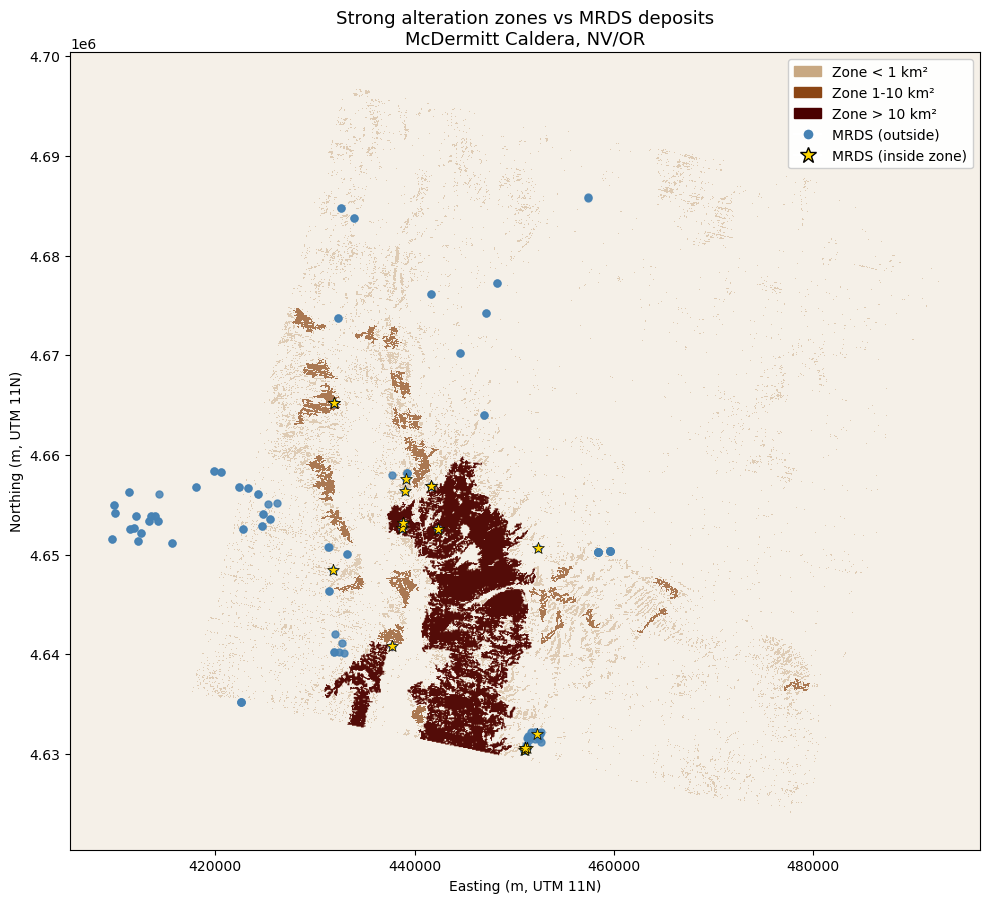

Saved.


In [25]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor('#f5f0e8')  # light tan background

# All zones in one color, outline only for small ones
zones[zones['area_km2'] < 1].plot(ax=ax, color='#c8a882', alpha=0.5, linewidth=0)
zones[zones['area_km2'] >= 1].plot(ax=ax, color='#8B4513', alpha=0.7, linewidth=0)
zones[zones['area_km2'] >= 10].plot(ax=ax, color='#4a0000', alpha=0.9, linewidth=0)

# Deposits
local_gdf.plot(ax=ax, color='steelblue', markersize=25, zorder=3,
               label='MRDS deposit (outside zones)', alpha=0.85)
hits_gdf = local_gdf[local_gdf.index.isin(hits.index)]
hits_gdf.plot(ax=ax, color='gold', markersize=80, marker='*', zorder=4,
              edgecolor='black', linewidth=0.5, label='MRDS deposit (inside zone)')

ax.set_title('Strong alteration zones vs MRDS deposits\nMcDermitt Caldera, NV/OR', fontsize=13)
ax.legend(loc='upper right', framealpha=0.95)
ax.set_xlabel('Easting (m, UTM 11N)')
ax.set_ylabel('Northing (m, UTM 11N)')

# Simple legend for zone tiers
from matplotlib.patches import Patch
zone_legend = [
    Patch(color='#c8a882', label='Zone < 1 km²'),
    Patch(color='#8B4513', label='Zone 1-10 km²'),
    Patch(color='#4a0000', label='Zone > 10 km²'),
]
ax.legend(handles=zone_legend + [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='MRDS (outside)'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=12, label='MRDS (inside zone)'),
], loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig('../figures/03_deposit_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

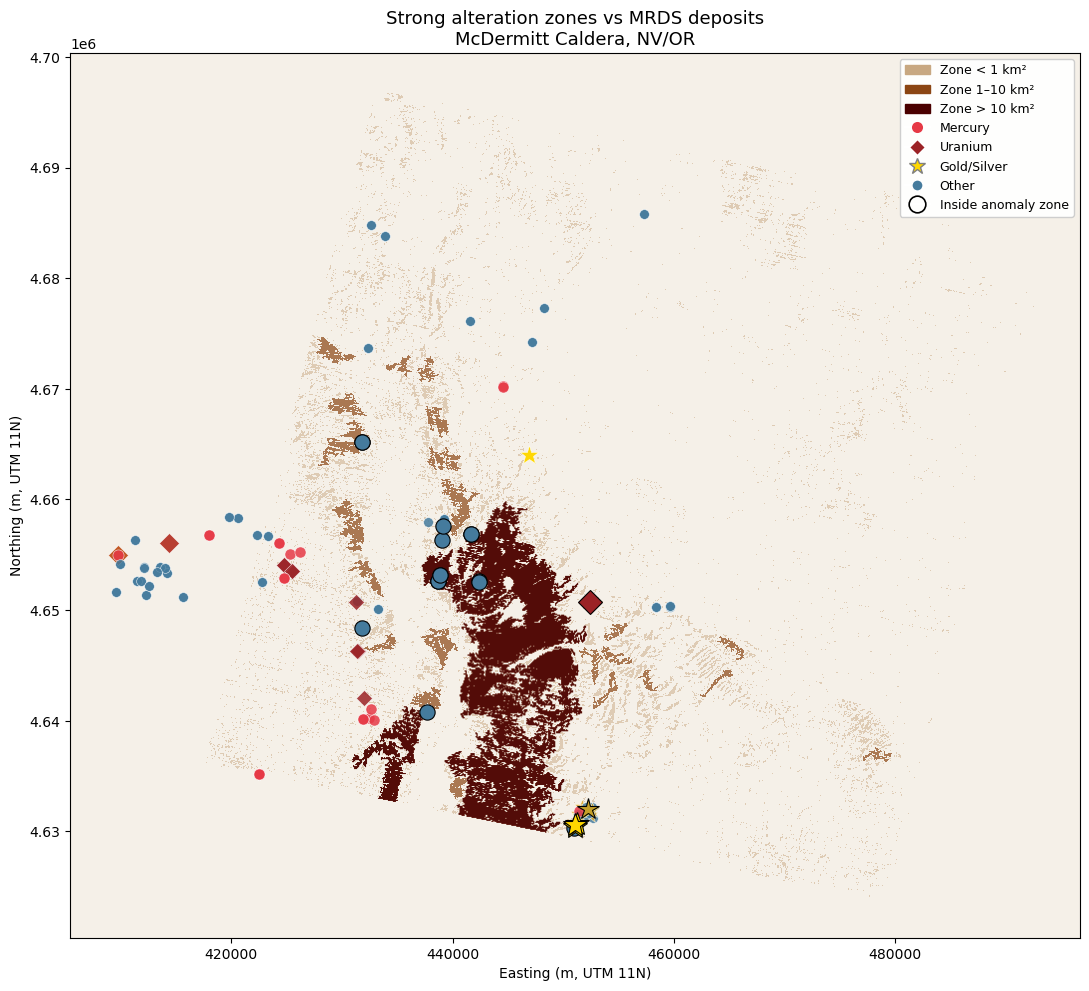

Saved.


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(11, 11))
ax.set_facecolor('#f5f0e8')

# Zones
zones[zones['area_km2'] < 1].plot(ax=ax, color='#c8a882', alpha=0.5, linewidth=0)
zones[zones['area_km2'] >= 1].plot(ax=ax, color='#8B4513', alpha=0.7, linewidth=0)
zones[zones['area_km2'] >= 10].plot(ax=ax, color='#4a0000', alpha=0.9, linewidth=0)

# Commodity symbology
commodity_styles = {
    'Mercury':   ('o', '#e63946', 8),
    'Uranium':   ('D', '#9b2226', 8),
    'Gold':      ('*', '#ffd700', 14),
    'Gold, Silver': ('*', '#daa520', 12),
    'Silver, Gold': ('*', '#c5a028', 12),
    'Lithium, Mercury, Uranium': ('D', '#ae2012', 10),
    'Mercury, Uranium, Lithium': ('D', '#bb3e03', 10),
}
default_style = ('o', '#457b9d', 7)

# Plot outside-zone deposits by commodity
for _, row in local_gdf[~local_gdf.index.isin(hits.index)].iterrows():
    style = commodity_styles.get(row['commod1'], default_style)
    ax.plot(row.geometry.x, row.geometry.y,
            marker=style[0], color=style[1], markersize=style[2],
            zorder=3, alpha=0.85, markeredgecolor='white', markeredgewidth=0.4)

# Plot inside-zone deposits on top, slightly larger
for _, row in hits_gdf.iterrows():
    style = commodity_styles.get(row['commod1'], default_style)
    ax.plot(row.geometry.x, row.geometry.y,
            marker=style[0], color=style[1], markersize=style[2]+4,
            zorder=5, alpha=1.0, markeredgecolor='black', markeredgewidth=0.8)

ax.set_title('Strong alteration zones vs MRDS deposits\nMcDermitt Caldera, NV/OR', fontsize=13)
ax.set_xlabel('Easting (m, UTM 11N)')
ax.set_ylabel('Northing (m, UTM 11N)')

# Legend
legend_elements = [
    mpatches.Patch(color='#c8a882', label='Zone < 1 km²'),
    mpatches.Patch(color='#8B4513', label='Zone 1–10 km²'),
    mpatches.Patch(color='#4a0000', label='Zone > 10 km²'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e63946', markersize=9, label='Mercury'),
    mlines.Line2D([], [], marker='D', color='w', markerfacecolor='#9b2226', markersize=8, label='Uranium'),
    mlines.Line2D([], [], marker='*', color='w', markerfacecolor='#ffd700', markersize=12, markeredgecolor='gray', label='Gold/Silver'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#457b9d', markersize=8, label='Other'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='none', markeredgecolor='black',
                  markeredgewidth=1.2, markersize=12, label='Inside anomaly zone'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.savefig('../figures/03_deposit_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

fig, ax = plt.subplots(figsize=(11, 11))
ax.set_facecolor('#f5f0e8')

# Zones -- warm browns, clearly distinct from deposit colors
zones[zones['area_km2'] < 1].plot(ax=ax, color='#d4a86a', alpha=0.5, linewidth=0)
zones[zones['area_km2'] >= 1].plot(ax=ax, color='#a05c1e', alpha=0.75, linewidth=0)
zones[zones['area_km2'] >= 10].plot(ax=ax, color='#4a1a00', alpha=0.95, linewidth=0)

# Wong palette -- no blue (reserved for nothing, since zones are brown)
commodity_map = {
    'Mercury':                    ('#E69F00', 'o', 10, 'Mercury'),       # orange
    'Uranium':                    ('#CC79A7', 'D', 9,  'Uranium'),       # pink
    'Gold':                       ('#F0E442', '*', 16, 'Gold/Silver'),   # yellow
    'Gold, Silver':               ('#F0E442', '*', 16, 'Gold/Silver'),
    'Silver, Gold':               ('#F0E442', '*', 16, 'Gold/Silver'),
    'Silver':                     ('#F0E442', '*', 14, 'Gold/Silver'),
    'Lithium, Mercury, Uranium':  ('#009E73', 's', 10, 'Li/U/Hg'),      # teal
    'Mercury, Uranium, Lithium':  ('#009E73', 's', 10, 'Li/U/Hg'),
    'Uranium, Mercury, Gold':     ('#009E73', 's', 10, 'Li/U/Hg'),
}
default = ('#555555', 'o', 7, 'Other')

plotted_labels = set()
for _, row in local_gdf.iterrows():
    style = commodity_map.get(row['commod1'], default)
    color, marker, size, label = style
    inside = row.name in hits.index
    edge = 'black' if inside else 'none'
    edgewidth = 1.2 if inside else 0
    lbl = label if label not in plotted_labels else None
    ax.plot(row.geometry.x, row.geometry.y,
            marker=marker, color=color, markersize=size,
            zorder=5, markeredgecolor=edge, markeredgewidth=edgewidth,
            label=lbl)
    plotted_labels.add(label)

ax.set_title('Strong alteration zones vs MRDS deposits\nMcDermitt Caldera, NV/OR', fontsize=13)
ax.set_xlabel('Easting (m, UTM 11N)')
ax.set_ylabel('Northing (m, UTM 11N)')
ax.tick_params(colors='black')

legend_elements = [
    mpatches.Patch(color='#d4a86a', label='Zone < 1 km²'),
    mpatches.Patch(color='#a05c1e', label='Zone 1–10 km²'),
    mpatches.Patch(color='#4a1a00', label='Zone > 10 km²'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#E69F00', markersize=10, label='Mercury'),
    mlines.Line2D([], [], marker='D', color='w', markerfacecolor='#CC79A7', markersize=9, label='Uranium'),
    mlines.Line2D([], [], marker='*', color='w', markerfacecolor='#F0E442', markeredgecolor='gray', markersize=14, label='Gold/Silver'),
    mlines.Line2D([], [], marker='s', color='w', markerfacecolor='#009E73', markersize=9, label='Li/U/Hg'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#555555', markersize=8, label='Other'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='none',
                  markeredgecolor='black', markeredgewidth=1.5, markersize=12, label='Inside anomaly zone'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.savefig('../figures/03_deposit_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

                 Outside zone  Inside zone  Total  % inside
commodity_group                                            
Antimony                    5            0      5       0.0
Lithium                     2            0      2       0.0
Mercury                    22            0     22       0.0
Stone                      54            3     57       5.3
Uranium                     8            1      9      11.1
Other                       3            1      4      25.0
Gold/Silver                14            6     20      30.0
Sand/Gravel                13           10     23      43.5


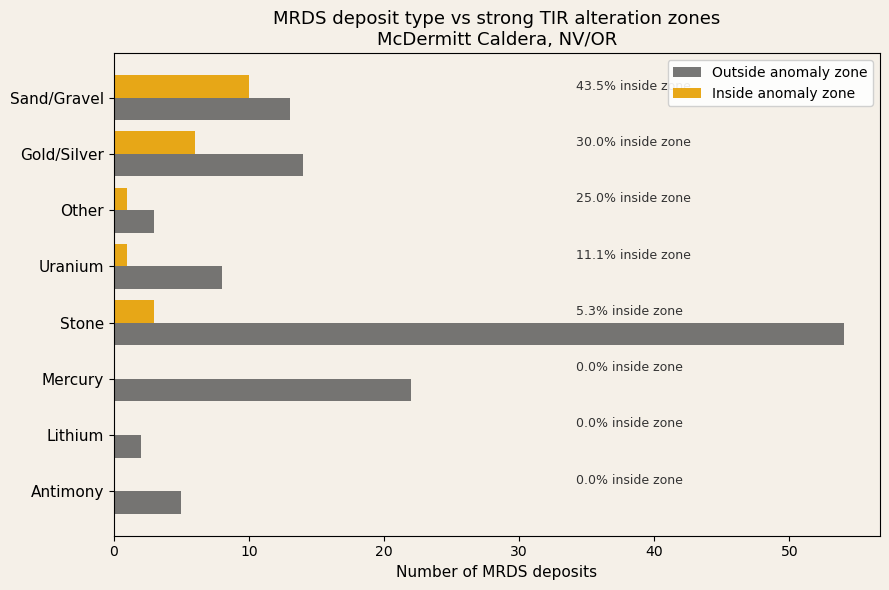

Saved.


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Build a summary table: for each commodity group, how many inside vs outside zones
local_gdf['inside_zone'] = local_gdf.index.isin(hits.index)

# Simplify commodity names
def simplify_commodity(c):
    c = str(c).lower()
    if 'lithium' in c: return 'Lithium'
    if 'mercury' in c: return 'Mercury'
    if 'uranium' in c: return 'Uranium'
    if 'gold' in c: return 'Gold/Silver'
    if 'silver' in c: return 'Gold/Silver'
    if 'antimony' in c: return 'Antimony'
    if 'sand' in c or 'gravel' in c: return 'Sand/Gravel'
    if 'stone' in c: return 'Stone'
    if 'gemstone' in c or 'semiprecious' in c: return 'Gemstone'
    return 'Other'

local_gdf['commodity_group'] = local_gdf['commod1'].apply(simplify_commodity)

# Crosstab: commodity vs inside/outside
ct = pd.crosstab(local_gdf['commodity_group'], local_gdf['inside_zone'],
                 colnames=['Inside zone'])
ct.columns = ['Outside zone', 'Inside zone']
ct['Total'] = ct.sum(axis=1)
ct['% inside'] = (ct['Inside zone'] / ct['Total'] * 100).round(1)
ct = ct.sort_values('% inside', ascending=True)

print(ct)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('#f5f0e8')
fig.patch.set_facecolor('#f5f0e8')

x = np.arange(len(ct))
width = 0.4

bars_out = ax.barh(x - width/2, ct['Outside zone'], width,
                   color='#555555', alpha=0.8, label='Outside anomaly zone')
bars_in  = ax.barh(x + width/2, ct['Inside zone'], width,
                   color='#E69F00', alpha=0.9, label='Inside anomaly zone')

ax.set_yticks(x)
ax.set_yticklabels(ct.index, fontsize=11)
ax.set_xlabel('Number of MRDS deposits', fontsize=11)
ax.set_title('MRDS deposit type vs strong TIR alteration zones\nMcDermitt Caldera, NV/OR', fontsize=13)
ax.legend(framealpha=0.9)

# Annotate % inside
for i, (_, row) in enumerate(ct.iterrows()):
    ax.text(ct['Total'].max() * 0.6, i + width/2,
            f"{row['% inside']}% inside zone",
            va='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.savefig('../figures/04_commodity_correlation.png', dpi=150, bbox_inches='tight',
            facecolor='#f5f0e8')
plt.show()
print("Saved.")